In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        (os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [7]:
from collections import defaultdict

class_counts = defaultdict(int)

DATASET_PATH = '/kaggle/input/dl-project-dataset/Building_Dataset'

for cls in os.listdir(DATASET_PATH):
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        count = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        class_counts[cls] = count

print("\n📊 Images per class:")
for cls, cnt in sorted(class_counts.items()):
    print(f"{cls:15s}: {cnt}")

print("\n🔢 Total:", sum(class_counts.values()))




📊 Images per class:
Wall           : 791
algae          : 520
major_crack    : 480
minor_crack    : 380
mold           : 154
normal         : 450
peeling        : 420
spalling       : 350
stain          : 380

🔢 Total: 3925


Device: cuda

================ FOLD 1 ================
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


Epoch 01 | Train Acc: 0.775
Epoch 02 | Train Acc: 0.881
Epoch 03 | Train Acc: 0.893
Epoch 04 | Train Acc: 0.921
Epoch 05 | Train Acc: 0.911
Fold 1 Validation Accuracy: 0.892
              precision    recall  f1-score   support

        Wall       1.00      1.00      1.00       159
       algae       0.99      0.91      0.95       104
 major_crack       0.90      0.62      0.74        96
 minor_crack       0.79      0.80      0.80        76
        mold       0.94      0.97      0.95        30
      normal       0.89      0.99      0.94        90
     peeling       0.79      0.98      0.87        84
    spalling       0.87      0.86      0.86        70
       stain       0.79      0.86      0.82        76

    accuracy                           0.89       785
   macro avg       0.88      0.89      0.88       785
weighted avg       0.90      0.89      0.89       785


================ FOLD 2 ================
Epoch 01 | Train Acc: 0.793
Epoch 02 | Train Acc: 0.866
Epoch 03 | Train Acc: 0

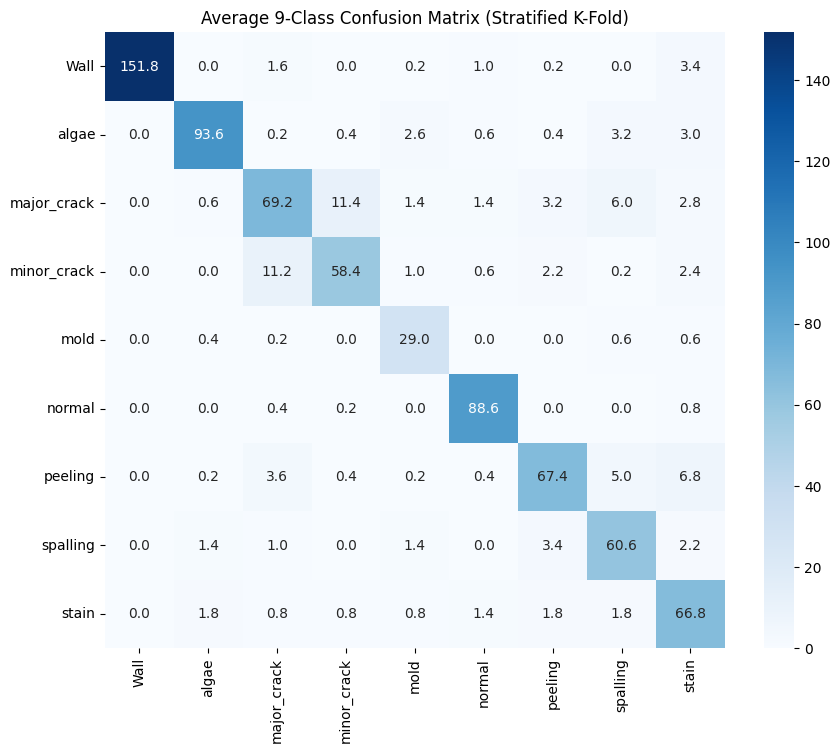

In [9]:
# ============================================================
# STRATIFIED K-FOLD MULTI-CLASS MOLD DETECTION (CLEAN)
# ============================================================

# ----------------------------
# 1. SETUP
# ----------------------------
import os, random, numpy as np, torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ----------------------------
# 2. DATASET
# ----------------------------
DATASET_PATH = "/kaggle/input/dl-project-dataset/Building_Dataset"

BIO_MAP = {
    "mold": 1, "algae": 1,
    "Wall": 0, "normal": 0, "stain": 0,
    "peeling": 0, "spalling": 0,
    "major_crack": 0, "minor_crack": 0
}

class MultiTaskDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.classes = sorted(os.listdir(root))
        self.class_to_idx = {c:i for i,c in enumerate(self.classes)}
        self.samples = []

        for cls in self.classes:
            for img in os.listdir(os.path.join(root, cls)):
                if img.lower().endswith((".jpg",".png",".jpeg")):
                    self.samples.append((cls, os.path.join(root, cls, img)))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        cls, path = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, self.class_to_idx[cls], BIO_MAP[cls]

# ----------------------------
# 3. TRANSFORMS
# ----------------------------
train_tfms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

eval_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ----------------------------
# 4. MODEL
# ----------------------------
class MultiTaskResNet50(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1
        )
        feat = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.class_head = nn.Linear(feat, num_classes)
        self.bio_head   = nn.Linear(feat, 2)

    def forward(self, x):
        f = self.backbone(x)
        return {"class": self.class_head(f), "bio": self.bio_head(f)}

# ----------------------------
# 5. DATASET INIT
# ----------------------------
full_ds = MultiTaskDataset(DATASET_PATH, train_tfms)
labels = np.array([full_ds[i][1] for i in range(len(full_ds))])
classes = full_ds.classes
num_classes = len(classes)

# ----------------------------
# 6. LOSS & K-FOLD
# ----------------------------
class_weights = torch.tensor([1,1.5,1,1,2,1,1,1,1.3]).to(device)
loss_class = nn.CrossEntropyLoss(weight=class_weights)
loss_bio   = nn.CrossEntropyLoss()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

fold_accuracies = []
fold_conf_matrices = []

# ----------------------------
# 7. STRATIFIED K-FOLD TRAINING
# ----------------------------
for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
    print(f"\n================ FOLD {fold+1} ================")

    train_ds = Subset(full_ds, train_idx)
    val_ds   = Subset(full_ds, val_idx)

    train_ds.dataset.transform = train_tfms
    val_ds.dataset.transform   = eval_tfms

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    model = MultiTaskResNet50(num_classes).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

    # ---- TRAIN ----
    for epoch in range(5):
        model.train()
        tr_loss, tr_p, tr_y = 0, [], []

        for x,y,b in train_loader:
            x,y,b = x.to(device), y.to(device), b.to(device)
            optimizer.zero_grad()

            out = model(x)
            loss = loss_class(out["class"],y) + 0.5*loss_bio(out["bio"],b)
            loss.backward()
            optimizer.step()

            tr_loss += loss.item()
            tr_p.extend(torch.argmax(out["class"],1).cpu().numpy())
            tr_y.extend(y.cpu().numpy())

        tr_acc = accuracy_score(tr_y, tr_p)
        print(f"Epoch {epoch+1:02d} | Train Acc: {tr_acc:.3f}")

    # ---- EVALUATE ONCE (IMPORTANT) ----
    model.eval()
    val_preds, val_labels = [], []

    with torch.no_grad():
        for x,y,b in val_loader:
            out = model(x.to(device))
            preds = torch.argmax(out["class"],1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(y.numpy())

    fold_acc = accuracy_score(val_labels, val_preds)
    fold_accuracies.append(fold_acc)

    cm = confusion_matrix(val_labels, val_preds)
    fold_conf_matrices.append(cm)

    print(f"Fold {fold+1} Validation Accuracy: {fold_acc:.3f}")
    print(classification_report(val_labels, val_preds, target_names=classes))

# ----------------------------
# 8. FINAL RESULTS
# ----------------------------
print("\n========== CROSS-VALIDATION RESULTS ==========")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.3f}")
print(f"Std Accuracy:  {np.std(fold_accuracies):.3f}")

# Average confusion matrix
avg_cm = np.mean(fold_conf_matrices, axis=0)

plt.figure(figsize=(10,8))
sns.heatmap(avg_cm, annot=True, fmt=".1f",
            xticklabels=classes, yticklabels=classes, cmap="Blues")
plt.title("Average 9-Class Confusion Matrix (Stratified K-Fold)")
plt.show()



===== 3-CLASS VALIDATION REPORT =====
               precision    recall  f1-score   support

         mold       1.00      0.77      0.87        31
possible_mold       0.99      0.98      0.99       650
      no_mold       0.88      0.96      0.92       104

     accuracy                           0.97       785
    macro avg       0.96      0.91      0.93       785
 weighted avg       0.97      0.97      0.97       785



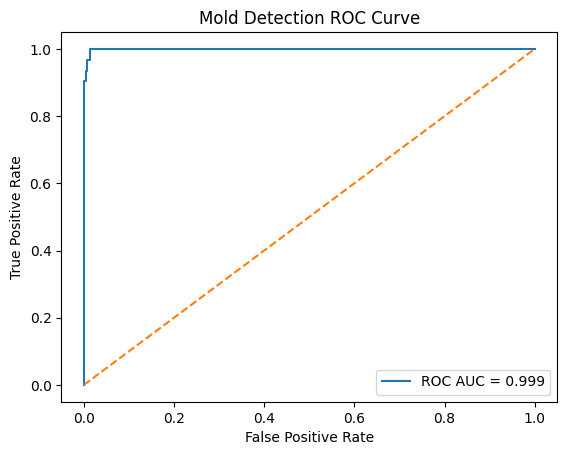

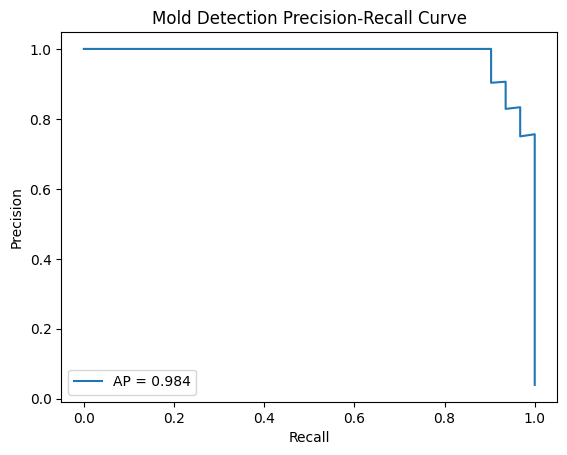

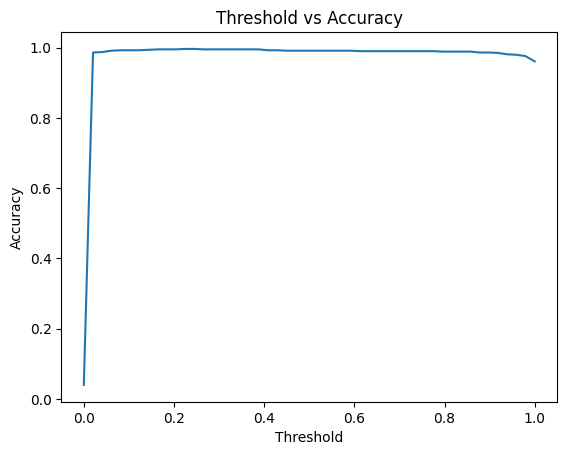

In [10]:
mold_idx = classes.index("mold")


model.eval()
val_class_logits = []
val_bio_logits   = []
val_labels_9     = []

with torch.no_grad():
    for x,y,b in val_loader:
        x = x.to(device)
        out = model(x)

        val_class_logits.append(out["class"].cpu())
        val_bio_logits.append(out["bio"].cpu())
        val_labels_9.extend(y.numpy())

val_class_logits = torch.cat(val_class_logits)
val_bio_logits   = torch.cat(val_bio_logits)
val_labels_9     = np.array(val_labels_9)

TH_MOLD = 0.80
TH_BIO  = 0.60

def refine_predictions(class_logits, bio_logits):
    cp = F.softmax(class_logits, dim=1)
    bp = F.softmax(bio_logits, dim=1)[:, 1]  # bio positive prob

    preds = []
    for pm, pb in zip(cp[:, mold_idx], bp):
        if pm >= TH_MOLD and pb >= TH_BIO:
            preds.append("mold")
        elif pb >= 0.5:
            preds.append("possible_mold")
        else:
            preds.append("no_mold")
    return preds


true_3 = []
for lbl in val_labels_9:
    cls = classes[lbl]
    if cls == "mold":
        true_3.append("mold")
    elif BIO_MAP[cls] == 1:
        true_3.append("possible_mold")
    else:
        true_3.append("no_mold")

pred_3 = refine_predictions(val_class_logits, val_bio_logits)


from sklearn.metrics import classification_report

print("\n===== 3-CLASS VALIDATION REPORT =====")
print(classification_report(
    true_3, pred_3,
    target_names=["mold", "possible_mold", "no_mold"]
))


mold_scores = (
    F.softmax(val_class_logits, dim=1)[:, mold_idx].numpy() *
    F.softmax(val_bio_logits, dim=1)[:, 1].numpy()
)

y_true_bin = np.array([1 if t == "mold" else 0 for t in true_3])


from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true_bin, mold_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Mold Detection ROC Curve")
plt.legend()
plt.show()


from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, _ = precision_recall_curve(y_true_bin, mold_scores)
ap = average_precision_score(y_true_bin, mold_scores)

plt.figure()
plt.plot(rec, prec, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Mold Detection Precision-Recall Curve")
plt.legend()
plt.show()


thresholds = np.linspace(0,1,50)
accs = []

for th in thresholds:
    preds = (mold_scores >= th).astype(int)
    accs.append(accuracy_score(y_true_bin, preds))

plt.figure()
plt.plot(thresholds, accs)
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Threshold vs Accuracy")
plt.show()


torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": classes,
    "TH_MOLD": TH_MOLD,
    "TH_BIO": TH_BIO
}, "multitask_mold_detector.pth")


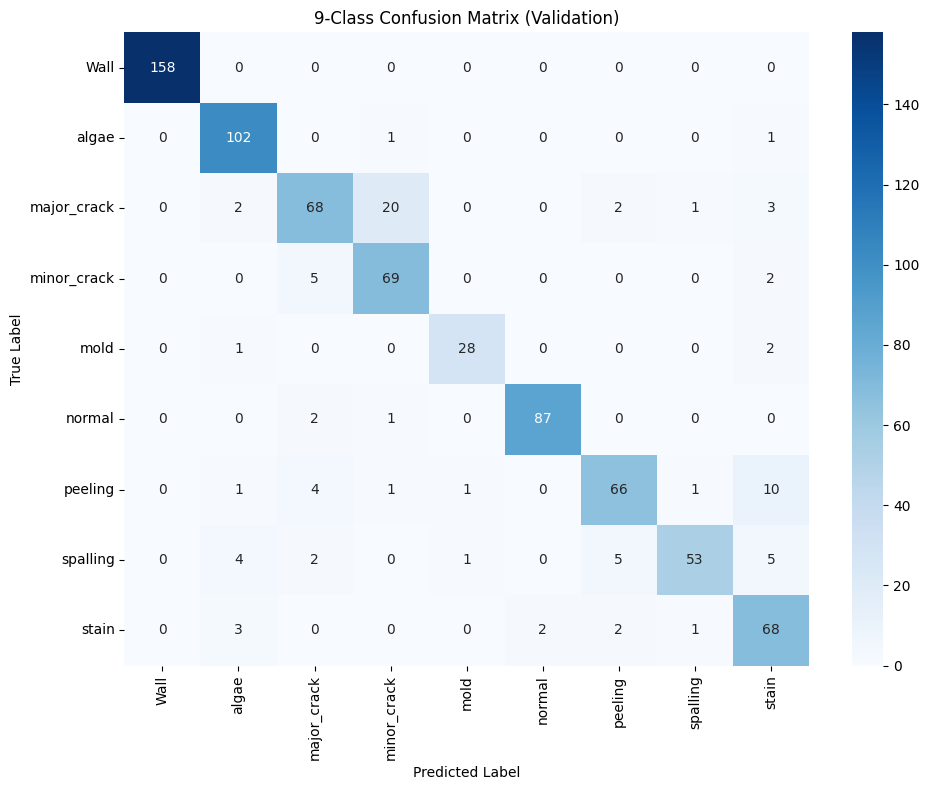

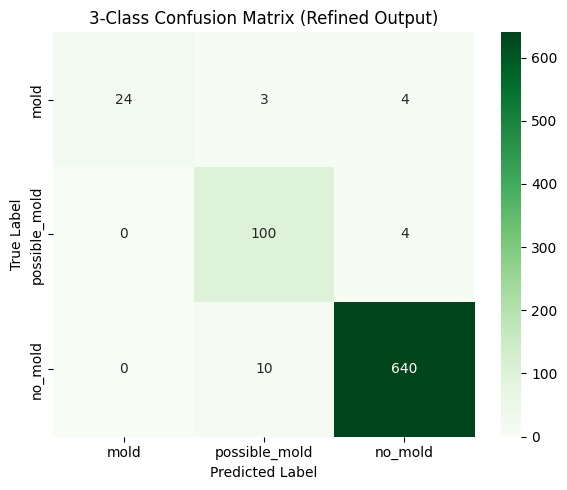


===== 9-CLASS VALIDATION CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        Wall     1.0000    1.0000    1.0000       158
       algae     0.9027    0.9808    0.9401       104
 major_crack     0.8395    0.7083    0.7684        96
 minor_crack     0.7500    0.9079    0.8214        76
        mold     0.9333    0.9032    0.9180        31
      normal     0.9775    0.9667    0.9721        90
     peeling     0.8800    0.7857    0.8302        84
    spalling     0.9464    0.7571    0.8413        70
       stain     0.7473    0.8947    0.8144        76

    accuracy                         0.8904       785
   macro avg     0.8863    0.8783    0.8784       785
weighted avg     0.8960    0.8904    0.8897       785


===== 3-CLASS VALIDATION CLASSIFICATION REPORT =====
               precision    recall  f1-score   support

         mold     1.0000    0.7742    0.8727        31
possible_mold     0.8850    0.9615    0.9217       104
      no_mold     0.9

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


# ============================================================
# 9-CLASS CONFUSION MATRIX
# ============================================================

preds_9 = torch.argmax(val_class_logits, dim=1).numpy()

cm_9 = confusion_matrix(val_labels_9, preds_9)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_9,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("9-Class Confusion Matrix (Validation)")
plt.tight_layout()
plt.show()


# ============================================================
# 3-CLASS CONFUSION MATRIX
# ============================================================

labels_3 = ["mold", "possible_mold", "no_mold"]

cm_3 = confusion_matrix(true_3, pred_3, labels=labels_3)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_3,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels_3,
    yticklabels=labels_3
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("3-Class Confusion Matrix (Refined Output)")
plt.tight_layout()
plt.show()


# ============================================================
# 9-CLASS CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

preds_9 = torch.argmax(val_class_logits, dim=1).numpy()

print("\n===== 9-CLASS VALIDATION CLASSIFICATION REPORT =====")
print(
    classification_report(
        val_labels_9,
        preds_9,
        target_names=classes,
        digits=4
    )
)


# ============================================================
# 3-CLASS CLASSIFICATION REPORT
# ============================================================

labels_3 = ["mold", "possible_mold", "no_mold"]

print("\n===== 3-CLASS VALIDATION CLASSIFICATION REPORT =====")
print(
    classification_report(
        true_3,
        pred_3,
        labels=labels_3,
        target_names=labels_3,
        digits=4
    )
)



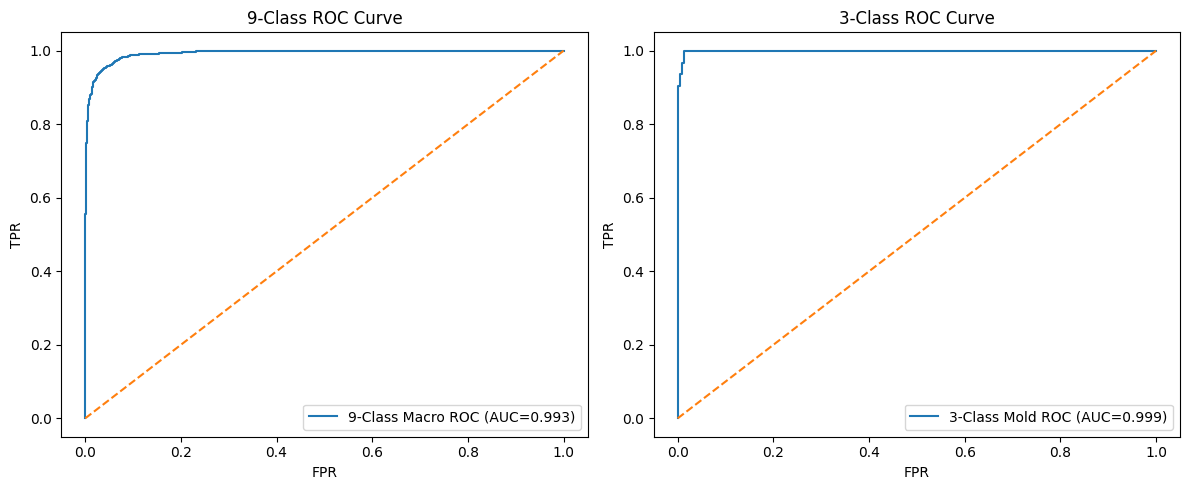

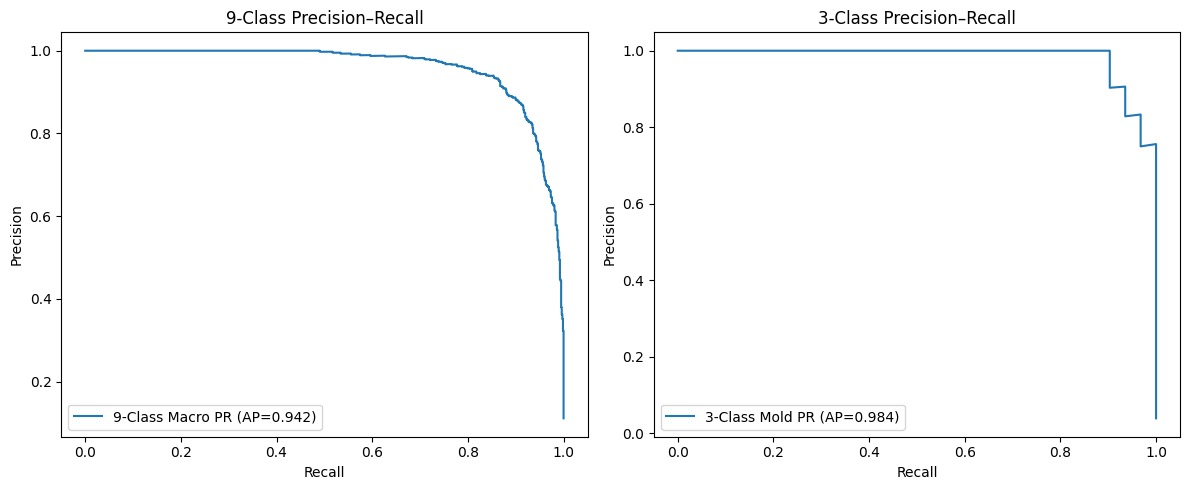

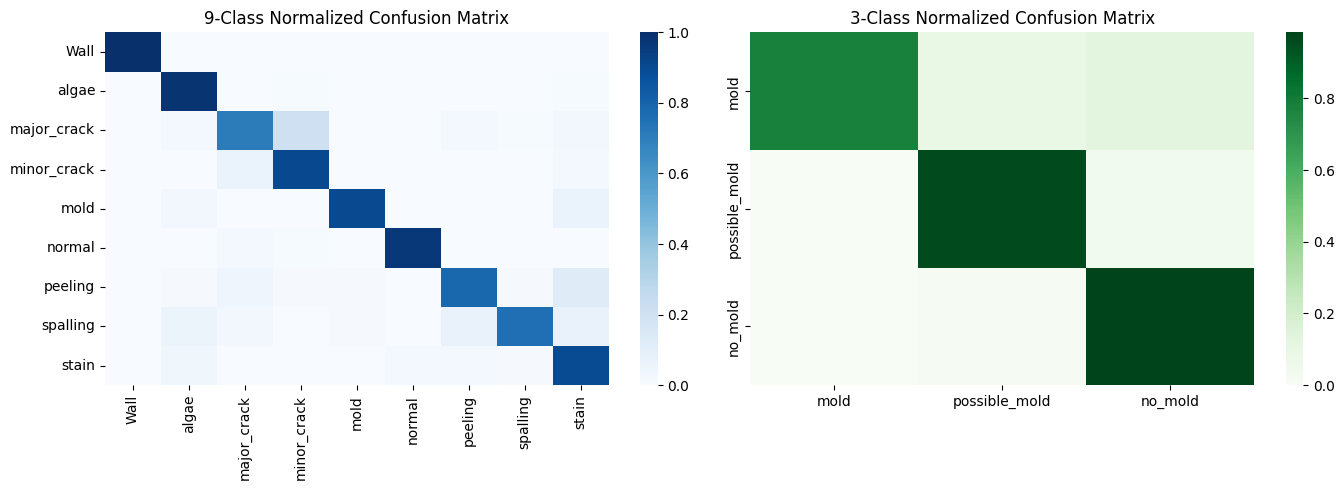

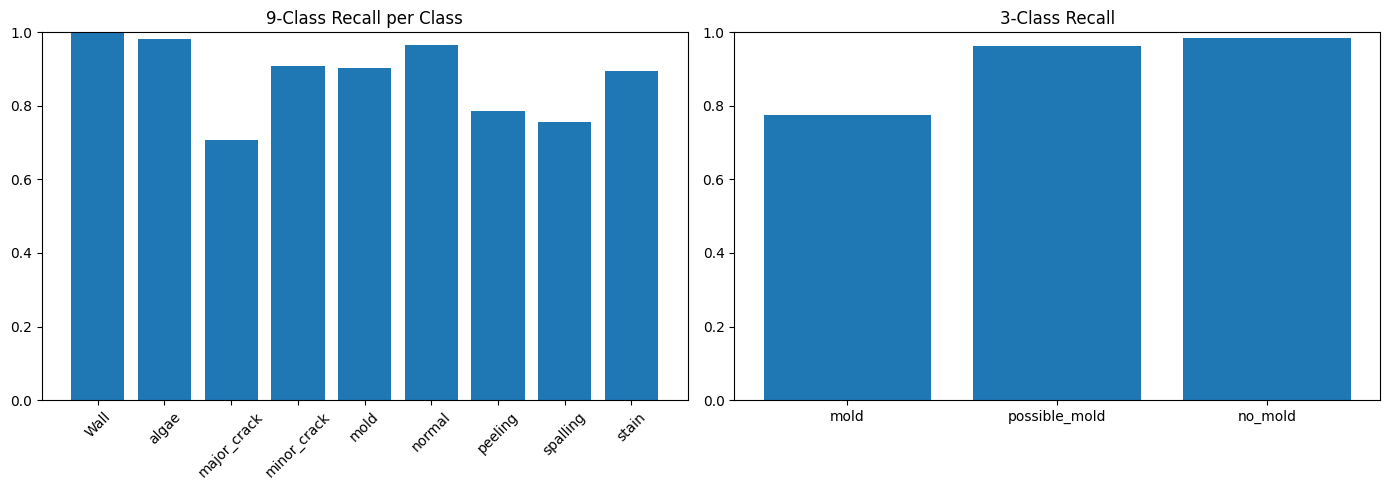

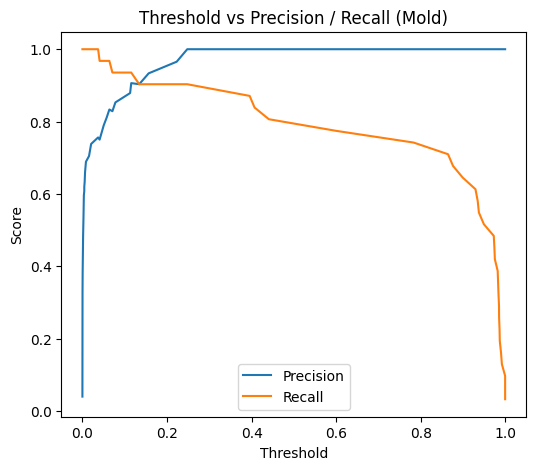

In [26]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# ---------- 9-CLASS ROC (macro-average) ----------
y_true_9_bin = label_binarize(val_labels_9, classes=np.arange(num_classes))
y_score_9 = F.softmax(val_class_logits, dim=1).numpy()

fpr_9, tpr_9, _ = roc_curve(
    y_true_9_bin.ravel(),
    y_score_9.ravel()
)
roc_auc_9 = auc(fpr_9, tpr_9)

# ---------- 3-CLASS ROC (mold vs rest) ----------
fpr_3, tpr_3, _ = roc_curve(y_true_bin, mold_scores)
roc_auc_3 = auc(fpr_3, tpr_3)

# ---------- PLOT ----------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_9, tpr_9, label=f"9-Class Macro ROC (AUC={roc_auc_9:.3f})")
plt.plot([0,1], [0,1], "--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("9-Class ROC Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fpr_3, tpr_3, label=f"3-Class Mold ROC (AUC={roc_auc_3:.3f})")
plt.plot([0,1], [0,1], "--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("3-Class ROC Curve")
plt.legend()

plt.tight_layout()
plt.show()


from sklearn.metrics import precision_recall_curve, average_precision_score

# ---------- 9-CLASS PR (macro) ----------
prec_9, rec_9, _ = precision_recall_curve(
    y_true_9_bin.ravel(),
    y_score_9.ravel()
)
ap_9 = average_precision_score(
    y_true_9_bin,
    y_score_9,
    average="macro"
)

# ---------- 3-CLASS PR ----------
prec_3, rec_3, _ = precision_recall_curve(y_true_bin, mold_scores)
ap_3 = average_precision_score(y_true_bin, mold_scores)

# ---------- PLOT ----------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(rec_9, prec_9, label=f"9-Class Macro PR (AP={ap_9:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("9-Class Precision–Recall")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(rec_3, prec_3, label=f"3-Class Mold PR (AP={ap_3:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("3-Class Precision–Recall")
plt.legend()

plt.tight_layout()
plt.show()


# Normalized confusion matrices
cm_9_norm = cm_9.astype(float) / cm_9.sum(axis=1, keepdims=True)
cm_3_norm = cm_3.astype(float) / cm_3.sum(axis=1, keepdims=True)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_9_norm, cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("9-Class Normalized Confusion Matrix")

plt.subplot(1, 2, 2)
sns.heatmap(cm_3_norm, cmap="Greens",
            xticklabels=labels_3, yticklabels=labels_3)
plt.title("3-Class Normalized Confusion Matrix")

plt.tight_layout()
plt.show()


from sklearn.metrics import recall_score

recall_9 = recall_score(val_labels_9, preds_9, average=None)
recall_3 = recall_score(true_3, pred_3, labels=labels_3, average=None)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(classes, recall_9)
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.title("9-Class Recall per Class")

plt.subplot(1, 2, 2)
plt.bar(labels_3, recall_3)
plt.ylim(0,1)
plt.title("3-Class Recall")

plt.tight_layout()
plt.show()


precisions, recalls, ths = precision_recall_curve(y_true_bin, mold_scores)

plt.figure(figsize=(6,5))
plt.plot(ths, precisions[:-1], label="Precision")
plt.plot(ths, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision / Recall (Mold)")
plt.legend()
plt.show()



=== Ground truth class: 'Wall' ===
Image 0: predicted='Wall' (prob=1.0000) | full_probs=[1. 0. 0. 0. 0. 0. 0. 0. 0.]


  0%|          | 0/1998 [00:00<?, ?it/s]

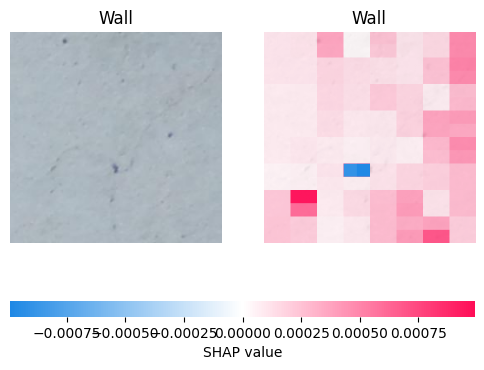

Image 1: predicted='Wall' (prob=1.0000) | full_probs=[1. 0. 0. 0. 0. 0. 0. 0. 0.]


  0%|          | 0/1998 [00:00<?, ?it/s]

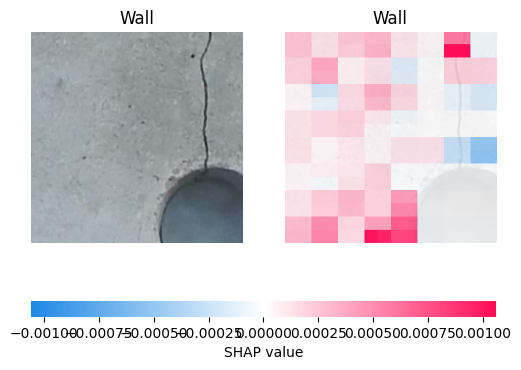


=== Ground truth class: 'algae' ===
Image 0: predicted='algae' (prob=1.0000) | full_probs=[0. 1. 0. 0. 0. 0. 0. 0. 0.]


  0%|          | 0/1998 [00:00<?, ?it/s]

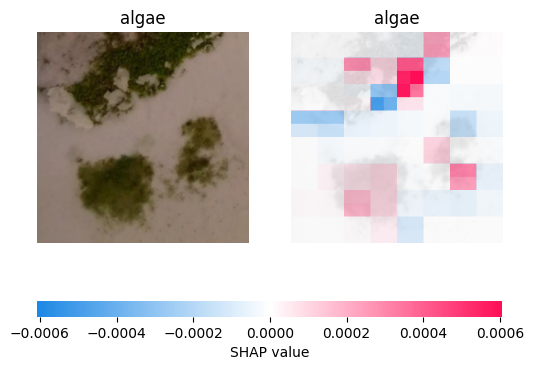

Image 1: predicted='algae' (prob=0.9993) | full_probs=[0.000e+00 9.993e-01 0.000e+00 0.000e+00 1.000e-04 0.000e+00 0.000e+00
 2.000e-04 3.000e-04]


  0%|          | 0/1998 [00:00<?, ?it/s]

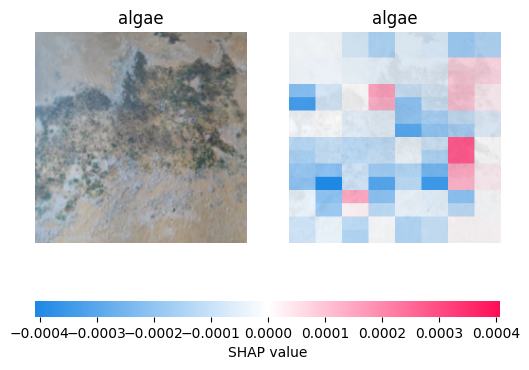


=== Ground truth class: 'major_crack' ===
Image 0: predicted='major_crack' (prob=0.6098) | full_probs=[0.0285 0.0112 0.6098 0.0749 0.0074 0.0022 0.0324 0.0178 0.2158]


  0%|          | 0/1998 [00:00<?, ?it/s]

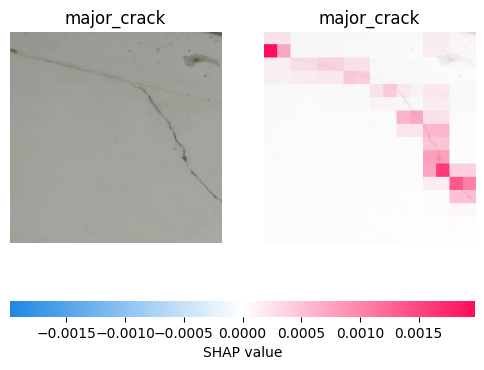

Image 1: predicted='major_crack' (prob=0.9357) | full_probs=[3.000e-04 0.000e+00 9.357e-01 4.590e-02 0.000e+00 0.000e+00 1.670e-02
 1.200e-03 1.000e-04]


  0%|          | 0/1998 [00:00<?, ?it/s]

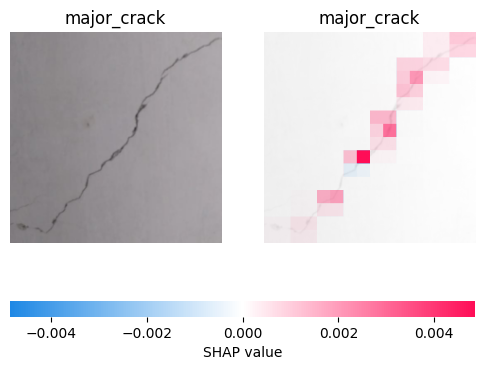


=== Ground truth class: 'minor_crack' ===
Image 0: predicted='minor_crack' (prob=0.9435) | full_probs=[1.000e-04 3.000e-04 4.450e-02 9.435e-01 1.000e-04 1.000e-04 7.600e-03
 1.700e-03 2.100e-03]


  0%|          | 0/1998 [00:00<?, ?it/s]

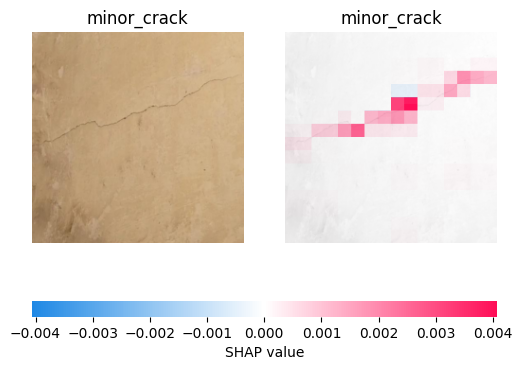

Image 1: predicted='minor_crack' (prob=0.8703) | full_probs=[0.000e+00 0.000e+00 1.253e-01 8.703e-01 0.000e+00 0.000e+00 2.200e-03
 2.000e-03 2.000e-04]


  0%|          | 0/1998 [00:00<?, ?it/s]

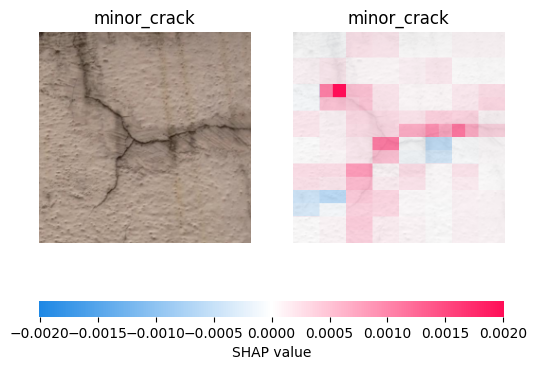


=== Ground truth class: 'mold' ===
Image 0: predicted='mold' (prob=0.9977) | full_probs=[0.000e+00 0.000e+00 5.000e-04 5.000e-04 9.977e-01 0.000e+00 1.000e-04
 0.000e+00 1.000e-03]


  0%|          | 0/1998 [00:00<?, ?it/s]

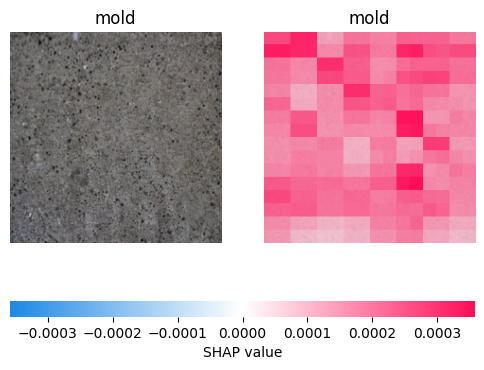

Image 1: predicted='mold' (prob=0.9985) | full_probs=[0.000e+00 0.000e+00 6.000e-04 4.000e-04 9.985e-01 0.000e+00 0.000e+00
 0.000e+00 5.000e-04]


  0%|          | 0/1998 [00:00<?, ?it/s]

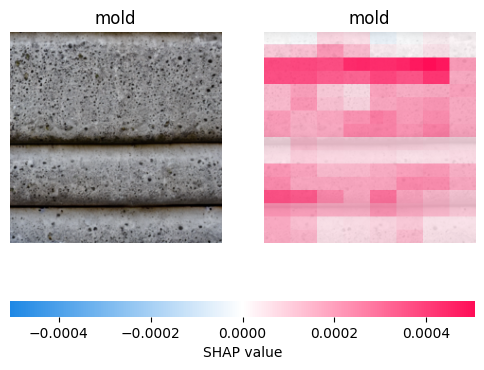


=== Ground truth class: 'normal' ===
Image 0: predicted='normal' (prob=0.9983) | full_probs=[0.000e+00 0.000e+00 2.000e-04 1.000e-04 0.000e+00 9.983e-01 0.000e+00
 1.000e-04 1.100e-03]


  0%|          | 0/1998 [00:00<?, ?it/s]

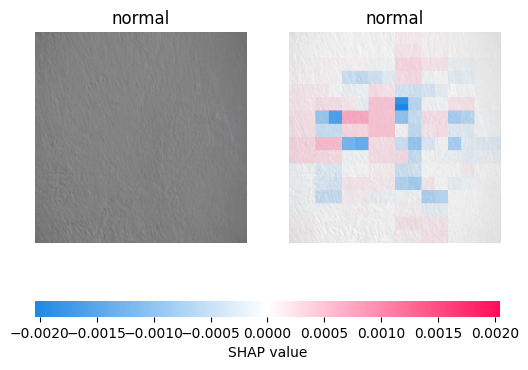

Image 1: predicted='normal' (prob=0.9956) | full_probs=[2.000e-04 1.000e-04 8.000e-04 1.300e-03 2.000e-04 9.956e-01 1.000e-04
 5.000e-04 1.400e-03]


  0%|          | 0/1998 [00:00<?, ?it/s]

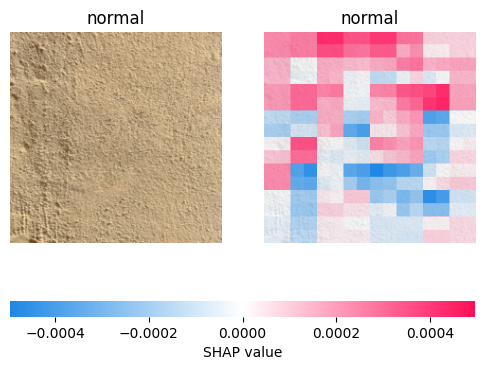


=== Ground truth class: 'peeling' ===
Image 0: predicted='peeling' (prob=0.9601) | full_probs=[3.000e-04 2.000e-03 1.300e-03 8.000e-04 5.000e-04 0.000e+00 9.601e-01
 3.300e-02 2.000e-03]


  0%|          | 0/1998 [00:00<?, ?it/s]

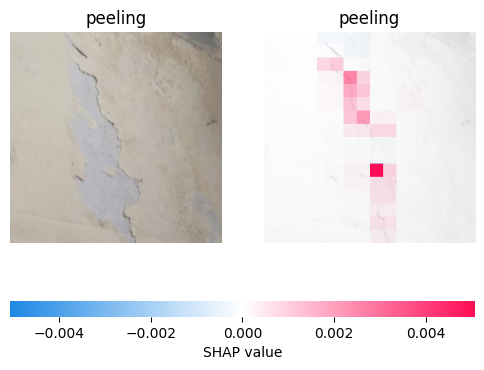

Image 1: predicted='peeling' (prob=0.9994) | full_probs=[0.000e+00 1.000e-04 0.000e+00 0.000e+00 0.000e+00 0.000e+00 9.994e-01
 4.000e-04 1.000e-04]


  0%|          | 0/1998 [00:00<?, ?it/s]

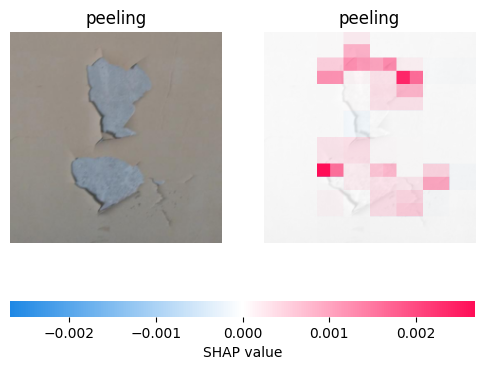


=== Ground truth class: 'spalling' ===
Image 0: predicted='peeling' (prob=0.4536) | full_probs=[0.0011 0.0973 0.0097 0.0013 0.0079 0.     0.4536 0.4266 0.0024]


  0%|          | 0/1998 [00:00<?, ?it/s]

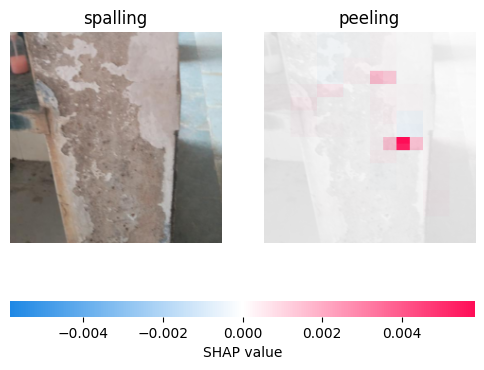

Image 1: predicted='spalling' (prob=0.9833) | full_probs=[0.     0.     0.     0.     0.     0.     0.0167 0.9833 0.    ]


  0%|          | 0/1998 [00:00<?, ?it/s]

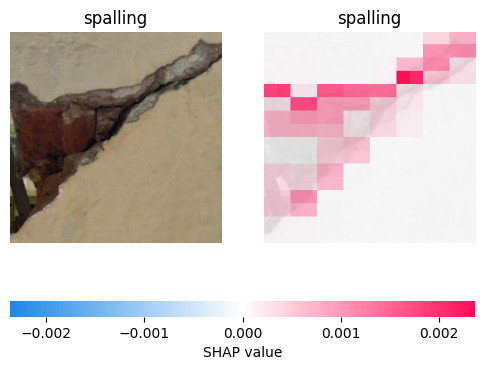


=== Ground truth class: 'stain' ===
Image 0: predicted='stain' (prob=0.9955) | full_probs=[0.000e+00 4.000e-04 2.000e-04 0.000e+00 5.000e-04 0.000e+00 0.000e+00
 3.400e-03 9.955e-01]


  0%|          | 0/1998 [00:00<?, ?it/s]

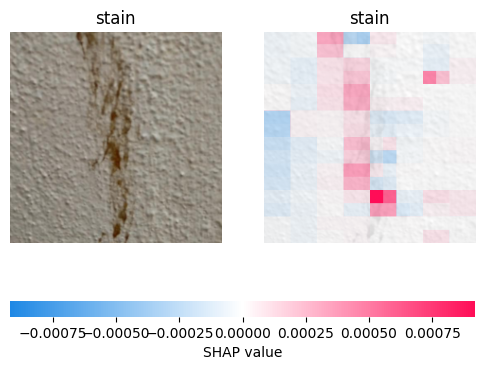

Image 1: predicted='stain' (prob=0.9827) | full_probs=[1.000e-04 1.200e-03 6.000e-04 7.100e-03 3.000e-04 1.200e-03 5.200e-03
 1.600e-03 9.827e-01]


  0%|          | 0/1998 [00:00<?, ?it/s]

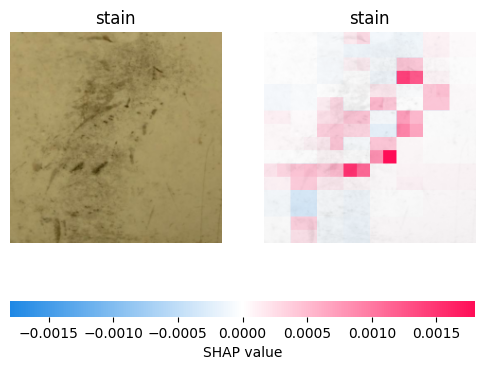

In [27]:
# ======================================================================
# SHAP HELPERS
# ======================================================================

import shap
import torch
import numpy as np

def unify_different_shap_output_formats(shap_values):
    """
    Normalize SHAP image outputs into the format expected by shap.image_plot.
    """
    vals = shap_values.values

    if isinstance(vals, list):
        return vals

    if isinstance(vals, np.ndarray) and vals.ndim == 5:
        # (N, H, W, C, outputs)
        return [vals[..., j] for j in range(vals.shape[-1])]

    if isinstance(vals, np.ndarray) and vals.ndim == 4:
        # (N, H, W, C)
        return [vals]

    raise ValueError(
        f"Unsupported SHAP values format: type={type(vals)}, shape={getattr(vals, 'shape', None)}"
    )


def torch_chw_to_nhwc_numpy01(t_chw_norm: torch.Tensor):
    """
    Convert normalized PyTorch tensor (CHW, ImageNet norm)
    to NumPy NHWC in [0,1].
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    x = t_chw_norm.unsqueeze(0).cpu()
    x = (x * std + mean).clamp(0, 1)
    x = x[0].permute(1, 2, 0).numpy()[None, ...]  # (1,H,W,3)
    return x


def predict_logits(x_np: np.ndarray) -> np.ndarray:
    """
    SHAP → PyTorch bridge.
    Returns 9-class logits (NOT probabilities).
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    x = torch.from_numpy(x_np).float().permute(0, 3, 1, 2)
    x = (x - mean) / std
    x = x.to(device)

    with torch.no_grad():
        out = model(x)
        logits = out["class"]  # 9-class head only

    return logits.cpu().numpy()


# ======================================================================
# SHAP SETUP
# ======================================================================

model.eval()

IMG_SIZE = 224
targets_per_class = 2

per_class = {c: [] for c in range(num_classes)}

for img, y, _ in val_ds:
    if len(per_class[y]) < targets_per_class:
        per_class[y].append(img)
    if all(len(v) == targets_per_class for v in per_class.values()):
        break

masker = shap.maskers.Image(
    "blur(8,8)",
    (IMG_SIZE, IMG_SIZE, 3)
)

explainer = shap.Explainer(
    predict_logits,
    masker,
    output_names=classes
)

# ======================================================================
# EXPLAIN + PLOT (ONE IMAGE AT A TIME)
# ======================================================================

for class_idx in range(num_classes):
    class_name = classes[class_idx]
    print(f"\n=== Ground truth class: '{class_name}' ===")

    for i, t in enumerate(per_class[class_idx]):

        # CHW → NHWC
        x1 = torch_chw_to_nhwc_numpy01(t)

        logits = predict_logits(x1)
        probs = np.exp(logits - logits.max(axis=1, keepdims=True))
        probs /= probs.sum(axis=1, keepdims=True)

        pred_idx = int(probs.argmax(axis=1)[0])
        pred_prob = float(probs[0, pred_idx])

        print(
            f"Image {i}: predicted='{classes[pred_idx]}' "
            f"(prob={pred_prob:.4f}) | full_probs={np.round(probs[0], 4)}"
        )

        shap_values = explainer(
            x1,
            outputs=[pred_idx],
            max_evals=2000,
            batch_size=16,
        )

        vals_list = unify_different_shap_output_formats(shap_values)

        shap.image_plot(
            shap_values=vals_list,
            pixel_values=x1,
            labels=[classes[pred_idx]],
            true_labels=[class_name],
        )


In [3]:
# ============================================================
# UNCERTAINTY-AWARE MOLD DETECTION (GPU-SAFE)
# ConvNeXt + Multi-Task + Stratified K-Fold + 3-Class
# ============================================================

import os, random, numpy as np, torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from torch.cuda.amp import autocast, GradScaler
from PIL import Image
from torch.amp import autocast, GradScaler

# ----------------------------
# 1. SETUP
# ----------------------------
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

BATCH_SIZE = 8        # SAFE FOR 16GB GPU
EPOCHS = 5
LR = 3e-4

# ----------------------------
# 2. DATASET
# ----------------------------
DATASET_PATH = "/kaggle/input/dl-project-dataset/Building_Dataset"

BIO_MAP = {
    "mold": 1, "algae": 1,
    "Wall": 0, "normal": 0, "stain": 0,
    "peeling": 0, "spalling": 0,
    "major_crack": 0, "minor_crack": 0
}

class MultiTaskDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.classes = sorted(os.listdir(root))
        self.class_to_idx = {c:i for i,c in enumerate(self.classes)}
        self.samples = []

        for cls in self.classes:
            for f in os.listdir(os.path.join(root, cls)):
                if f.lower().endswith((".jpg",".png",".jpeg")):
                    self.samples.append((cls, os.path.join(root, cls, f)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        cls, path = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.class_to_idx[cls], BIO_MAP[cls]

# ----------------------------
# 3. TRANSFORMS
# ----------------------------
train_tfms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3,0.3,0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

eval_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ----------------------------
# 4. MODEL (FIXED ConvNeXt)
# ----------------------------
class MultiTaskConvNeXt(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.convnext_base(
            weights=models.ConvNeXt_Base_Weights.IMAGENET1K_V1
        )
        feat_dim = self.backbone.classifier[2].in_features
        self.backbone.classifier = nn.Identity()
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.class_head = nn.Linear(feat_dim, num_classes)
        self.bio_head   = nn.Linear(feat_dim, 2)

    def forward(self, x):
        f = self.backbone.features(x)
        f = self.pool(f)
        f = torch.flatten(f, 1)
        return {
            "class": self.class_head(f),
            "bio":   self.bio_head(f)
        }

# ----------------------------
# 5. FOCAL LOSS
# ----------------------------
class FocalLoss(nn.Module):
    def __init__(self, gamma=2, weight=None):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=weight)

    def forward(self, logits, targets):
        ce = self.ce(logits, targets)
        p = torch.exp(-ce)
        return (1 - p)**self.gamma * ce

# ----------------------------
# 6. STRATIFIED K-FOLD TRAINING
# ----------------------------
dataset = MultiTaskDataset(DATASET_PATH, train_tfms)
labels = np.array([dataset[i][1] for i in range(len(dataset))])
classes = dataset.classes
mold_idx = classes.index("mold")

class_weights = torch.tensor([1,1.5,1,1,2,1,1,1,1.3]).to(device)
loss_class = FocalLoss(weight=class_weights)
loss_bio = nn.CrossEntropyLoss()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scaler = GradScaler("cuda")

best_acc = 0.0

for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
    print(f"\n===== FOLD {fold+1} =====")

    train_ds = Subset(dataset, tr_idx)
    val_ds   = Subset(dataset, va_idx)
    train_ds.dataset.transform = train_tfms
    val_ds.dataset.transform   = eval_tfms

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)

    model = MultiTaskConvNeXt(len(classes)).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    # ---- TRAIN ----
    for epoch in range(EPOCHS):
        model.train()
        for x, y, b in train_loader:
            x, y, b = x.to(device), y.to(device), b.to(device)
            optimizer.zero_grad()
    
            with autocast(device_type="cuda"):
                out = model(x)
                loss = loss_class(out["class"], y) + 0.5 * loss_bio(out["bio"], b)
                #print(loss)
    
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        print(f"Epoch {epoch+1}/{EPOCHS} completed")

    # ---- VALIDATE ONCE ----
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for x,y,b in val_loader:
            out = model(x.to(device))
            p = torch.argmax(out["class"], 1)
            preds.extend(p.cpu().numpy())
            gts.extend(y.numpy())

    acc = np.mean(np.array(preds) == np.array(gts))
    print(f"Fold Accuracy: {acc:.3f}")

    if acc > best_acc:
        best_acc = acc
        torch.save({
            "model": model.state_dict(),
            "classes": classes
        }, "/kaggle/working/best_convnext_multitask.pth")

    del model
    torch.cuda.empty_cache()

# ----------------------------
# 7. LOAD BEST MODEL
# ----------------------------
ckpt = torch.load("/kaggle/working/best_convnext_multitask.pth", map_location=device)
model = MultiTaskConvNeXt(len(ckpt["classes"])).to(device)
model.load_state_dict(ckpt["model"])
model.eval()

# ----------------------------
# 8. 9 → 3 CLASS REFINEMENT
# ----------------------------
TH_MOLD = 0.80
TH_BIO  = 0.60

def refine_predictions(class_logits, bio_logits):
    cp = F.softmax(class_logits, dim=1)
    bp = F.softmax(bio_logits, dim=1)[:,1]
    refined = []
    for pm, pb in zip(cp[:, mold_idx], bp):
        if pm >= TH_MOLD and pb >= TH_BIO:
            refined.append("mold")
        elif pb >= 0.5:
            refined.append("possible_mold")
        else:
            refined.append("no_mold")
    return refined

# ----------------------------
# 9. FINAL 3-CLASS EVALUATION
# ----------------------------
true_3, pred_3 = [], []

with torch.no_grad():
    for x,y,b in DataLoader(dataset, batch_size=BATCH_SIZE):
        out = model(x.to(device))
        preds = refine_predictions(out["class"], out["bio"])
        pred_3.extend(preds)

        for lbl in y:
            if lbl.item() == mold_idx:
                true_3.append("mold")
            elif BIO_MAP[classes[lbl]] == 1:
                true_3.append("possible_mold")
            else:
                true_3.append("no_mold")

print("\n===== 3-CLASS CLASSIFICATION REPORT =====")
print(classification_report(true_3, pred_3))


Device: cuda

===== FOLD 1 =====
Epoch 1/5 completed
Epoch 2/5 completed
Epoch 3/5 completed
Epoch 4/5 completed
Epoch 5/5 completed
Fold Accuracy: 0.847

===== FOLD 2 =====
Epoch 1/5 completed
Epoch 2/5 completed
Epoch 3/5 completed
Epoch 4/5 completed
Epoch 5/5 completed
Fold Accuracy: 0.789

===== FOLD 3 =====
Epoch 1/5 completed
Epoch 2/5 completed
Epoch 3/5 completed
Epoch 4/5 completed
Epoch 5/5 completed
Fold Accuracy: 0.880

===== FOLD 4 =====
Epoch 1/5 completed
Epoch 2/5 completed
Epoch 3/5 completed
Epoch 4/5 completed
Epoch 5/5 completed
Fold Accuracy: 0.901

===== FOLD 5 =====
Epoch 1/5 completed
Epoch 2/5 completed
Epoch 3/5 completed
Epoch 4/5 completed
Epoch 5/5 completed
Fold Accuracy: 0.862

===== 3-CLASS CLASSIFICATION REPORT =====
               precision    recall  f1-score   support

         mold       0.99      0.69      0.82       154
      no_mold       0.99      1.00      0.99      3251
possible_mold       0.92      0.98      0.95       520

     accuracy    


===== 9-CLASS CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        Wall     0.9871    0.9684    0.9776       158
       algae     0.9806    0.9712    0.9758       104
 major_crack     0.9326    0.8646    0.8973        96
 minor_crack     0.8471    0.9474    0.8944        76
        mold     1.0000    0.9355    0.9667        31
      normal     0.9362    0.9778    0.9565        90
     peeling     0.8526    0.9643    0.9050        84
    spalling     0.9811    0.7429    0.8455        70
       stain     0.8902    0.9605    0.9241        76

    accuracy                         0.9325       785
   macro avg     0.9342    0.9258    0.9270       785
weighted avg     0.9364    0.9325    0.9319       785


===== 3-CLASS CLASSIFICATION REPORT =====
               precision    recall  f1-score   support

         mold     1.0000    0.8387    0.9123        31
possible_mold     0.9924    0.9985    0.9954       650
      no_mold     0.9524    0.9615    0.956

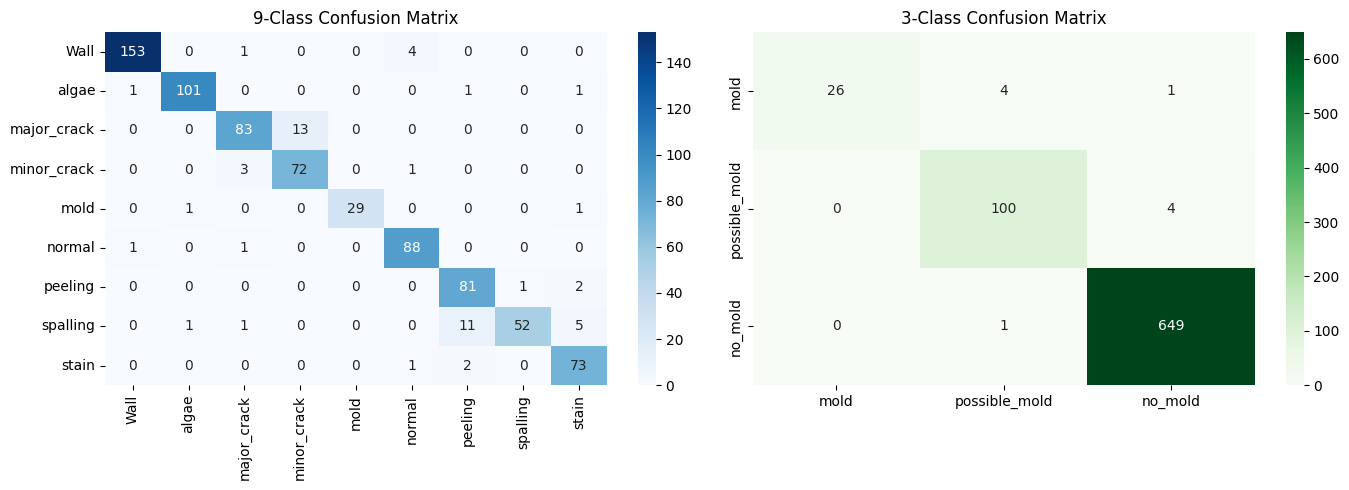

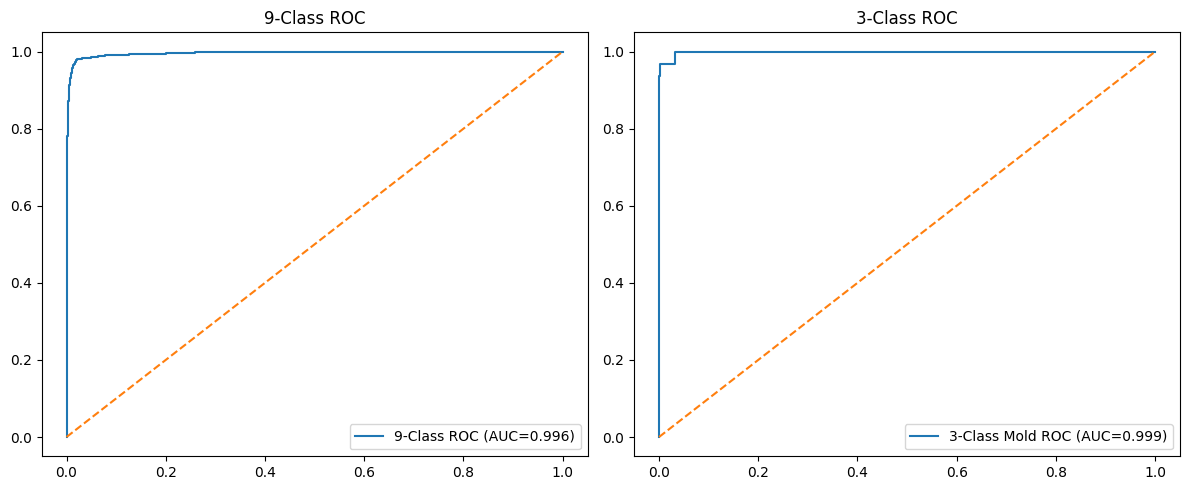

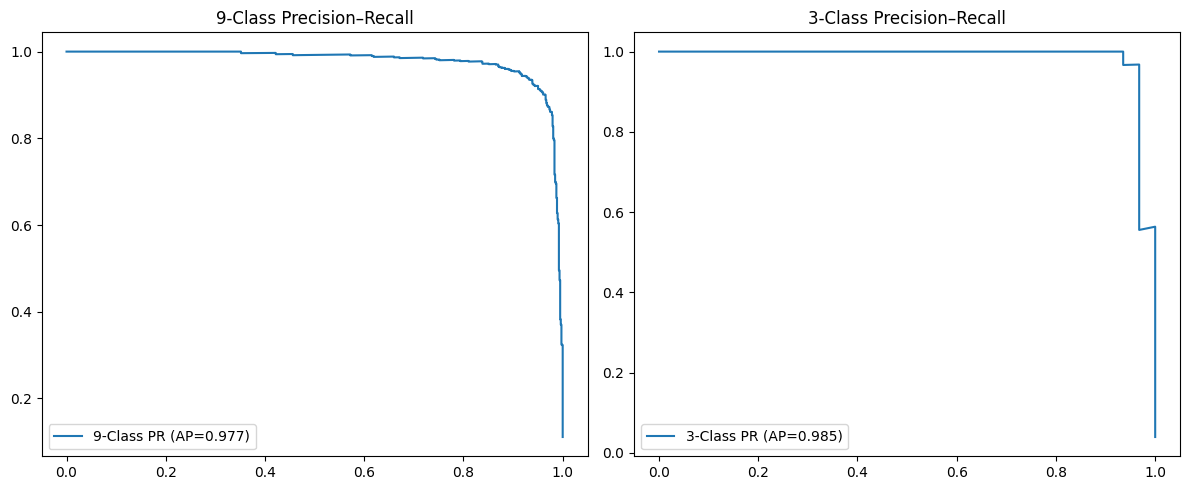

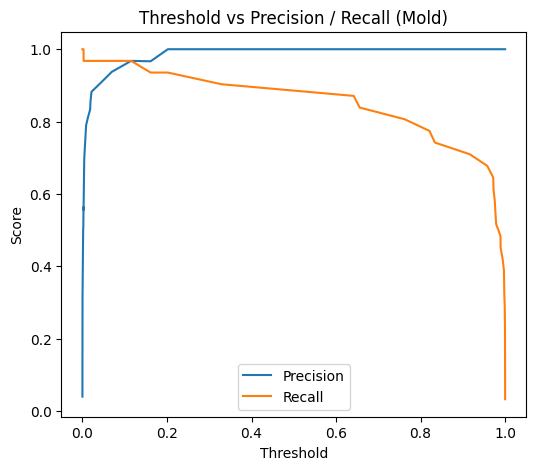

In [31]:
# ============================================================
# CONVNEXT MULTITASK — FULL EVALUATION & PLOTS
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    recall_score
)
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader

BATCH_SIZE = 8   # same as training, GPU-safe


# ----------------------------
# 1. LOAD SAVED MODEL
# ----------------------------
CKPT_PATH = "/kaggle/input/convnext/pytorch/default/1/best_convnext_multitask.pth"

ckpt = torch.load(CKPT_PATH, map_location=device)
classes = ckpt["classes"]
num_classes = len(classes)
mold_idx = classes.index("mold")

model = MultiTaskConvNeXt(num_classes).to(device)
model.load_state_dict(ckpt["model"])
model.eval()

# ----------------------------
# 2. RUN INFERENCE ON VALIDATION DATASET
# ----------------------------
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

val_class_logits = []
val_bio_logits   = []
val_labels_9     = []

with torch.no_grad():
    for x, y, b in val_loader:
        x = x.to(device)
        out = model(x)

        val_class_logits.append(out["class"].cpu())
        val_bio_logits.append(out["bio"].cpu())
        val_labels_9.extend(y.numpy())

val_class_logits = torch.cat(val_class_logits)
val_bio_logits   = torch.cat(val_bio_logits)
val_labels_9     = np.array(val_labels_9)

# ----------------------------
# 3. 9-CLASS METRICS
# ----------------------------
preds_9 = torch.argmax(val_class_logits, dim=1).numpy()

print("\n===== 9-CLASS CLASSIFICATION REPORT =====")
print(classification_report(val_labels_9, preds_9, target_names=classes, digits=4))

cm_9 = confusion_matrix(val_labels_9, preds_9)

# ----------------------------
# 4. 9 → 3 CLASS REFINEMENT
# ----------------------------
TH_MOLD = 0.80
TH_BIO  = 0.60

def refine_predictions(class_logits, bio_logits):
    cp = F.softmax(class_logits, dim=1)
    bp = F.softmax(bio_logits, dim=1)[:, 1]
    preds = []
    for pm, pb in zip(cp[:, mold_idx], bp):
        if pm >= TH_MOLD and pb >= TH_BIO:
            preds.append("mold")
        elif pb >= 0.5:
            preds.append("possible_mold")
        else:
            preds.append("no_mold")
    return preds

pred_3 = refine_predictions(val_class_logits, val_bio_logits)

true_3 = []
for lbl in val_labels_9:
    cls = classes[lbl]
    if cls == "mold":
        true_3.append("mold")
    elif BIO_MAP[cls] == 1:
        true_3.append("possible_mold")
    else:
        true_3.append("no_mold")

labels_3 = ["mold", "possible_mold", "no_mold"]

print("\n===== 3-CLASS CLASSIFICATION REPORT =====")
print(classification_report(true_3, pred_3, target_names=labels_3, digits=4))

cm_3 = confusion_matrix(true_3, pred_3, labels=labels_3)

# ----------------------------
# 5. CONFUSION MATRICES (SIDE BY SIDE)
# ----------------------------
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.heatmap(cm_9, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("9-Class Confusion Matrix")

plt.subplot(1,2,2)
sns.heatmap(cm_3, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels_3, yticklabels=labels_3)
plt.title("3-Class Confusion Matrix")

plt.tight_layout()
plt.show()

# ----------------------------
# 6. ROC–AUC (9-CLASS MACRO vs 3-CLASS MOLD)
# ----------------------------
y_true_9_bin = label_binarize(val_labels_9, classes=np.arange(num_classes))
y_score_9 = F.softmax(val_class_logits, dim=1).numpy()

fpr_9, tpr_9, _ = roc_curve(y_true_9_bin.ravel(), y_score_9.ravel())
roc_auc_9 = auc(fpr_9, tpr_9)

mold_scores = (
    F.softmax(val_class_logits, dim=1)[:, mold_idx].numpy() *
    F.softmax(val_bio_logits, dim=1)[:, 1].numpy()
)
y_true_bin = np.array([1 if t == "mold" else 0 for t in true_3])

fpr_3, tpr_3, _ = roc_curve(y_true_bin, mold_scores)
roc_auc_3 = auc(fpr_3, tpr_3)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(fpr_9, tpr_9, label=f"9-Class ROC (AUC={roc_auc_9:.3f})")
plt.plot([0,1],[0,1],"--")
plt.legend()
plt.title("9-Class ROC")

plt.subplot(1,2,2)
plt.plot(fpr_3, tpr_3, label=f"3-Class Mold ROC (AUC={roc_auc_3:.3f})")
plt.plot([0,1],[0,1],"--")
plt.legend()
plt.title("3-Class ROC")

plt.tight_layout()
plt.show()

# ----------------------------
# 7. PRECISION–RECALL CURVES
# ----------------------------
prec_9, rec_9, _ = precision_recall_curve(
    y_true_9_bin.ravel(), y_score_9.ravel()
)
ap_9 = average_precision_score(y_true_9_bin, y_score_9, average="macro")

prec_3, rec_3, ths = precision_recall_curve(y_true_bin, mold_scores)
ap_3 = average_precision_score(y_true_bin, mold_scores)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(rec_9, prec_9, label=f"9-Class PR (AP={ap_9:.3f})")
plt.legend()
plt.title("9-Class Precision–Recall")

plt.subplot(1,2,2)
plt.plot(rec_3, prec_3, label=f"3-Class PR (AP={ap_3:.3f})")
plt.legend()
plt.title("3-Class Precision–Recall")

plt.tight_layout()
plt.show()

# ----------------------------
# 8. THRESHOLD vs PRECISION / RECALL (3-CLASS)
# ----------------------------
plt.figure(figsize=(6,5))
plt.plot(ths, prec_3[:-1], label="Precision")
plt.plot(ths, rec_3[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision / Recall (Mold)")
plt.legend()
plt.show()



=== Ground Truth Class: 'Wall' ===
Image 0: predicted='Wall' (prob=0.9850) | probs=[9.85e-01 1.00e-04 1.60e-03 1.30e-03 7.00e-04 4.80e-03 1.10e-03 1.10e-03
 4.30e-03]


  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:20, 20.52s/it]               


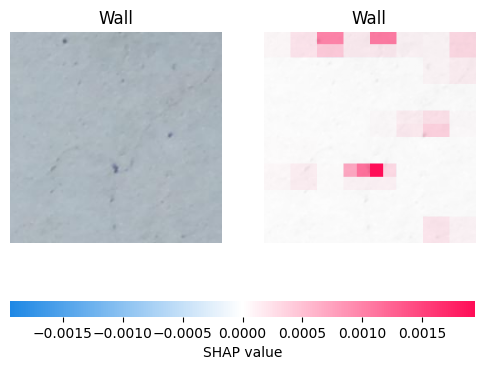


=== Ground Truth Class: 'algae' ===
Image 0: predicted='algae' (prob=0.9999) | probs=[0.000e+00 9.999e-01 0.000e+00 0.000e+00 1.000e-04 0.000e+00 0.000e+00
 0.000e+00 0.000e+00]


  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:17, 17.31s/it]               


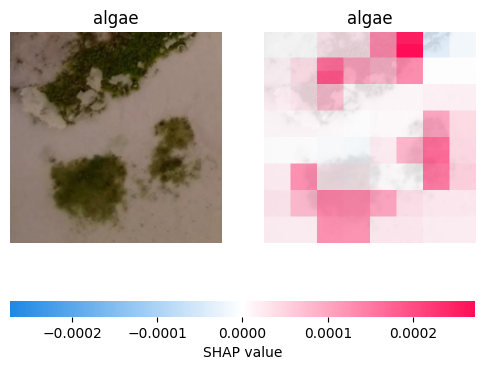


=== Ground Truth Class: 'major_crack' ===
Image 0: predicted='major_crack' (prob=0.5511) | probs=[1.640e-02 6.000e-04 5.511e-01 3.842e-01 5.000e-04 8.000e-03 1.270e-02
 3.800e-03 2.280e-02]


  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:17, 17.47s/it]               


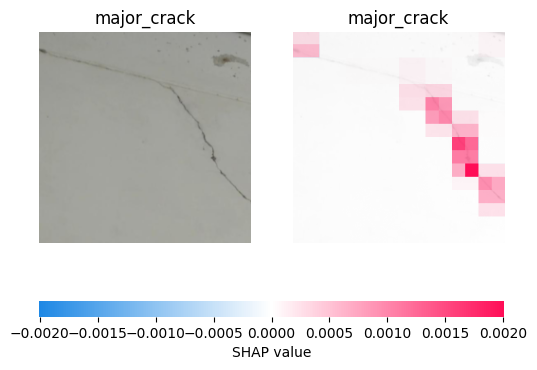


=== Ground Truth Class: 'minor_crack' ===
Image 0: predicted='minor_crack' (prob=0.9837) | probs=[2.000e-04 0.000e+00 1.280e-02 9.837e-01 0.000e+00 1.200e-03 6.000e-04
 1.000e-04 1.400e-03]


  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:17, 17.58s/it]               


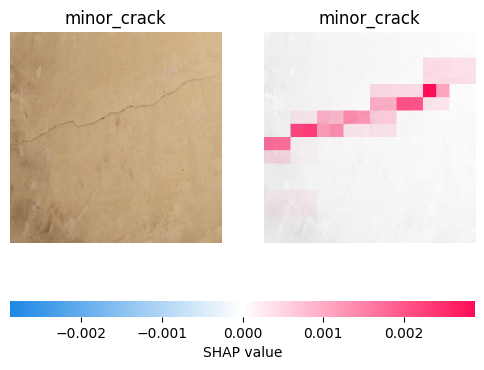


=== Ground Truth Class: 'mold' ===
Image 0: predicted='mold' (prob=0.2755) | probs=[0.005  0.0974 0.0135 0.0255 0.2755 0.2261 0.0539 0.1637 0.1395]


  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:17, 17.81s/it]               


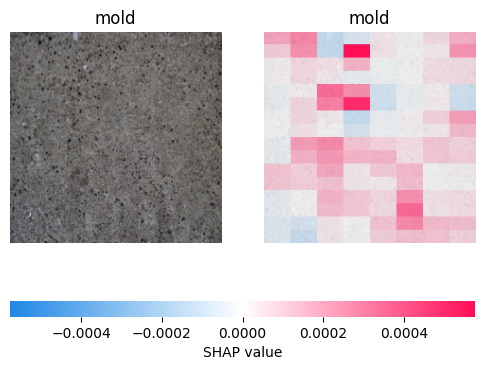


=== Ground Truth Class: 'normal' ===
Image 0: predicted='normal' (prob=0.9940) | probs=[7.00e-04 0.00e+00 8.00e-04 1.20e-03 0.00e+00 9.94e-01 5.00e-04 5.00e-04
 2.20e-03]


  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:17, 17.86s/it]               


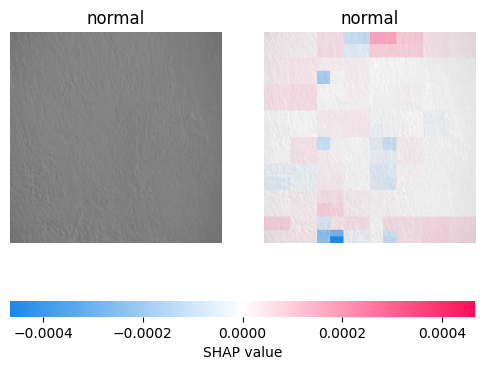


=== Ground Truth Class: 'peeling' ===
Image 0: predicted='peeling' (prob=0.9852) | probs=[7.000e-04 0.000e+00 5.100e-03 7.000e-03 0.000e+00 0.000e+00 9.852e-01
 1.700e-03 2.000e-04]


  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:17, 17.97s/it]               


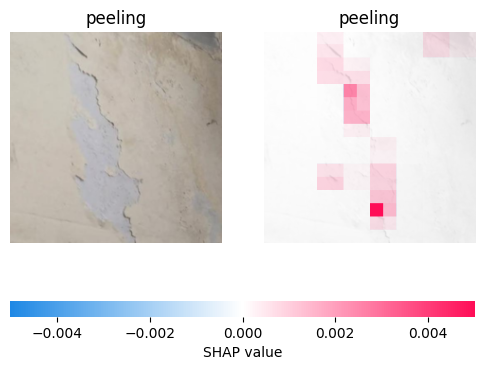


=== Ground Truth Class: 'spalling' ===
Image 0: predicted='peeling' (prob=0.8053) | probs=[1.000e-04 1.000e-04 1.460e-02 7.000e-04 0.000e+00 0.000e+00 8.053e-01
 1.789e-01 2.000e-04]


  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:17, 17.97s/it]               


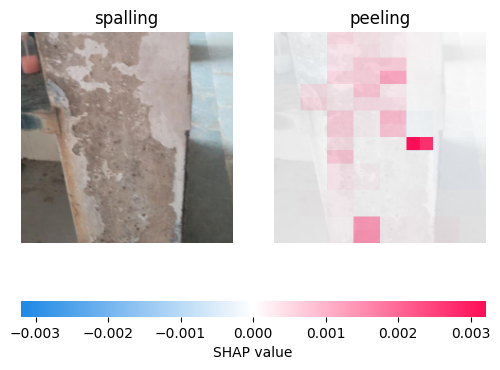


=== Ground Truth Class: 'stain' ===
Image 0: predicted='stain' (prob=0.9994) | probs=[0.000e+00 1.000e-04 0.000e+00 1.000e-04 0.000e+00 0.000e+00 2.000e-04
 2.000e-04 9.994e-01]


  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:18, 18.04s/it]               


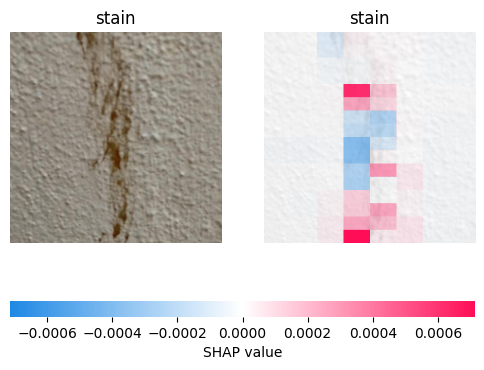

In [32]:
# ============================================================
# SHAP EXPLAINABILITY FOR CONVNEXT MULTITASK MODEL
# ============================================================

import shap
import numpy as np
import torch

# ----------------------------
# 1. SHAP HELPER FUNCTIONS
# ----------------------------

def unify_different_shap_output_formats(shap_values):
    """
    Normalize SHAP image outputs into the format expected by shap.image_plot.
    """
    vals = shap_values.values

    if isinstance(vals, list):
        return vals

    if isinstance(vals, np.ndarray) and vals.ndim == 5:
        # (N, H, W, C, outputs)
        return [vals[..., j] for j in range(vals.shape[-1])]

    if isinstance(vals, np.ndarray) and vals.ndim == 4:
        # (N, H, W, C)
        return [vals]

    raise ValueError(
        f"Unsupported SHAP values format: type={type(vals)}, shape={getattr(vals, 'shape', None)}"
    )


def torch_chw_to_nhwc_numpy01(t_chw_norm: torch.Tensor):
    """
    Convert ImageNet-normalized PyTorch tensor (CHW)
    to NumPy NHWC image in [0,1].
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    x = t_chw_norm.unsqueeze(0).cpu()
    x = (x * std + mean).clamp(0, 1)
    x = x[0].permute(1, 2, 0).numpy()[None, ...]  # (1,H,W,3)
    return x


def predict_logits(x_np: np.ndarray) -> np.ndarray:
    """
    SHAP -> PyTorch bridge.
    Input: NHWC [0,1]
    Output: 9-class logits
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    x = torch.from_numpy(x_np).float().permute(0, 3, 1, 2)
    x = (x - mean) / std
    x = x.to(device)

    with torch.no_grad():
        out = model(x)
        logits = out["class"]  # 9-class head only

    return logits.cpu().numpy()

# ----------------------------
# 2. SHAP SETUP
# ----------------------------

model.eval()
IMG_SIZE = 224
TARGETS_PER_CLASS = 1   # keep small for speed

# pick a few validation images per class
per_class = {i: [] for i in range(len(classes))}

for img, y, _ in val_ds:
    if len(per_class[y]) < TARGETS_PER_CLASS:
        per_class[y].append(img)
    if all(len(v) == TARGETS_PER_CLASS for v in per_class.values()):
        break

masker = shap.maskers.Image(
    "blur(8,8)",
    (IMG_SIZE, IMG_SIZE, 3)
)

explainer = shap.Explainer(
    predict_logits,
    masker,
    output_names=classes
)

# ----------------------------
# 3. EXPLAIN & PLOT
# ----------------------------

for class_idx in range(len(classes)):
    class_name = classes[class_idx]
    print(f"\n=== Ground Truth Class: '{class_name}' ===")

    for i, t in enumerate(per_class[class_idx]):

        # CHW -> NHWC [0,1]
        x1 = torch_chw_to_nhwc_numpy01(t)

        # prediction
        logits = predict_logits(x1)
        probs = np.exp(logits - logits.max(axis=1, keepdims=True))
        probs /= probs.sum(axis=1, keepdims=True)

        pred_idx = int(probs.argmax(axis=1)[0])
        pred_prob = float(probs[0, pred_idx])

        print(
            f"Image {i}: predicted='{classes[pred_idx]}' "
            f"(prob={pred_prob:.4f}) | probs={np.round(probs[0], 4)}"
        )

        shap_values = explainer(
            x1,
            outputs=[pred_idx],
            max_evals=1500,
            batch_size=16,
        )

        vals_list = unify_different_shap_output_formats(shap_values)

        shap.image_plot(
            shap_values=vals_list,
            pixel_values=x1,
            labels=[classes[pred_idx]],
            true_labels=[class_name],
        )
